In [55]:
from tensorflow.keras.datasets import fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

print(train_images.shape)
print(test_images.shape)

(60000, 28, 28)
(10000, 28, 28)


In [56]:


test_images.shape ##test 10000


(10000, 28, 28)

In [57]:
'''1. Məlumat setinin hazırlanması:
Fashion MNIST datasetini yükləyin və normallaşdıraraq təlimə hazır vəziyyətə gətirin. Siniflər aşağıdakı
kimidir:'''

'1. Məlumat setinin hazırlanması:\nFashion MNIST datasetini yükləyin və normallaşdıraraq təlimə hazır vəziyyətə gətirin. Siniflər aşağıdakı\nkimidir:'

In [58]:
from sklearn.preprocessing import normalize
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Dropout ,GRU, Flatten, Conv2D, MaxPooling2D,Input,BatchNormalization,Activation,GlobalAveragePooling2D,AveragePooling2D
from tensorflow import keras
from keras.callbacks import History
from tensorflow.keras.optimizers import SGD,Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import Sequential
from keras.activations import *
import matplotlib.pyplot as plt
import numpy as np
import time
import tensorflow as tf
from tensorflow.keras import layers, models

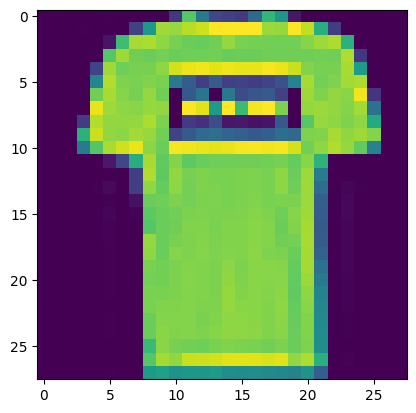

In [59]:
plt.imshow(train_images[1])

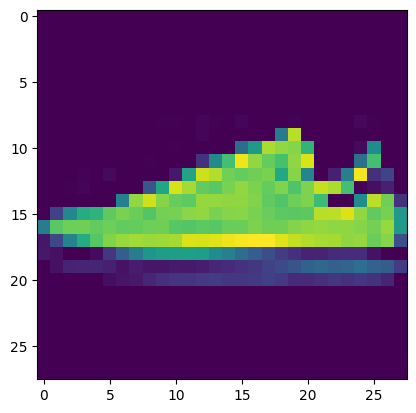

In [60]:
plt.imshow(train_images[6])

In [61]:

train_images = train_images.astype('float32') / 255 ##normallasdiramq ucun 255 e bolurem  ag pixel 255  bundan sonra seklim 0 255 arasi olur
test_images = test_images.astype('float32') / 2

In [62]:
'''

2. CNN Modelinin qurulması:
Aşağıdakı arxitekturaya malik Konvolyusiya Neyron Şəbəkəsi (CNN) qurun:
'''

'\n\n2. CNN Modelinin qurulması:\nAşağıdakı arxitekturaya malik Konvolyusiya Neyron Şəbəkəsi (CNN) qurun:\n'

In [63]:
train_labels = to_categorical(train_labels)##one code encode dir
test_labels = to_categorical(test_labels)

In [64]:
model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu', padding = 'same', input_shape = (28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64, (3,3), activation='relu', padding = 'same'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(10, activation='softmax'))





In [65]:
'''
3. Modelin təlimi (Training):
Modeli aşağıdakı parametrlərlə təlimə verin:
Optimallaşdırıcı: ADAM alqoritmi.
'''

'\n3. Modelin təlimi (Training):\nModeli aşağıdakı parametrlərlə təlimə verin:\nOptimallaşdırıcı: ADAM alqoritmi.\n'

In [66]:
adam = Adam(learning_rate=0.001) ##0.001 eledim lossu dah yaxsi tapsin
model.compile(optimizer=adam,loss='categorical_crossentropy',metrics=["categorical_accuracy"])
##coxlu sinfim var deye categorical_crossentropy yazdim (10 sinif var) sinif var mende
##iki sinif olsa binary_crossentropy yaziriq
##regresison meselesi olsa means sqeuared error yazaram

In [67]:
history = History()

In [68]:
def sch(epochs, lr):
    if epochs < 10:
        return lr
    else:
        return lr * np.exp(-0.1)

In [69]:
lrs = tf.keras.callbacks.LearningRateScheduler(sch)
early = tf.keras.callbacks.EarlyStopping(monitor='val_categorical_accuracy', patience=15)## 15 epoch boyunca artmasa train dayandir



In [70]:
model.fit(train_images,train_labels,epochs=25,callbacks=[history,lrs,early],validation_data=(test_images,test_labels),batch_size = 256)


Epoch 1/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - categorical_accuracy: 0.7810 - loss: 0.6258 - val_categorical_accuracy: 0.8355 - val_loss: 30.8761 - learning_rate: 0.0010
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - categorical_accuracy: 0.8796 - loss: 0.3360 - val_categorical_accuracy: 0.8663 - val_loss: 21.8334 - learning_rate: 0.0010
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - categorical_accuracy: 0.8981 - loss: 0.2812 - val_categorical_accuracy: 0.8677 - val_loss: 24.4618 - learning_rate: 0.0010
Epoch 4/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - categorical_accuracy: 0.9090 - loss: 0.2494 - val_categorical_accuracy: 0.8811 - val_loss: 20.8537 - learning_rate: 0.0010
Epoch 5/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - categorical_accuracy: 0.9173 - loss: 0.2257 - val_categorical_accuracy: 0.8710 - val_loss: 20.3452 - learning_rate: 0.0010
Epoch 6/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - categorical_accuracy: 0.9262 - loss: 0.2037 - val_categorica

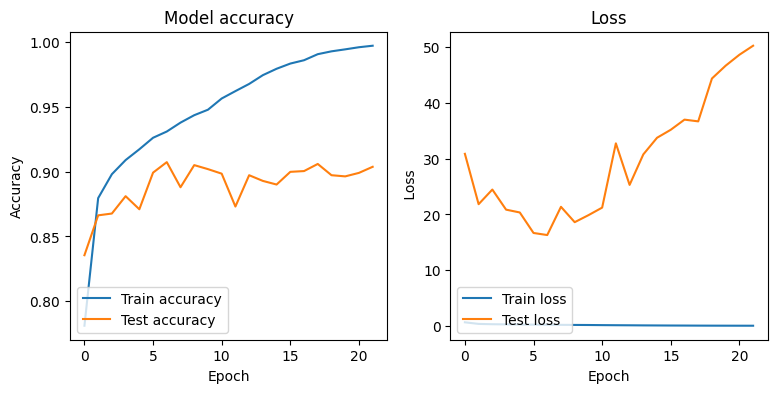

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,4))

plt.subplot(1,2,1)
plt.plot(history.history['categorical_accuracy'])
plt.plot(history.history['val_categorical_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train accuracy', 'Test accuracy'], loc='lower left')

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.ylabel(' Loss')
plt.xlabel('Epoch')
plt.legend(['Train loss', 'Test loss'], loc='lower left')

## qrafikde eger train xetti yuxari test xetti asagi dusubse model ezberleyib, amma tetbiq ede bilemyib demkedir

### eyni istiqametde yeni arasaindaki mesafe azdirsa demeli tetbiq ede bilib

##ikinci loss qrafikinde  asagi dusurse demeli model xetalari azaldir

In [ ]:
'''
5. Cümləni tokenlərə ayırın.
Alınan tokenlərin siyahısını yazın.
İzah edin ki, tokenization bu cümlə üçün nə etdi.
Sonra Word2Vec istifadə edin.


'''

In [ ]:
corpus = [
    "Artificial intelligence is changing the world.",
    "Machine learning helps computers learn from data.",
    "Natural language processing allows machines to understand text.",
    "Deep learning is a powerful branch of machine learning.",
    "Word embeddings represent words as numerical vectors.",
    "Word2Vec is a popular model for learning word embeddings.",
    "Tokenization splits text into smaller units called tokens.",
    "A sentence can be divided into words using tokenization.",
    "Language models are useful for many text processing tasks.",
    "Computers can analyze large amounts of textual data.",
    "Students are learning about artificial intelligence in class.",
    "The teacher explained how machine learning works.",
    "Python is widely used for natural language processing.",
    "Gensim provides tools for training Word2Vec models.",
    "Text data must be cleaned before training a model.",
    "Words that appear in similar contexts often have similar meanings.",
    "A model can learn semantic relationships between words.",
    "Artificial and intelligence are related words in many contexts.",
    "Natural and language often appear together in documents.",
    "Processing text requires careful preparation of data.",
    "Data scientists use algorithms to solve real problems.",
    "Neural networks can identify patterns in language data.",
    "The model improved after training on more sentences.",
    "A larger corpus usually gives better word representations.",
    "Small datasets may lead to weak vector quality.",
    "Training data is important for machine learning performance.",
    "Word vectors can capture similarity between terms.",
    "Researchers use embeddings in translation systems.",
    "Chatbots rely on language models to answer questions.",
    "Speech recognition also uses natural language techniques.",
    "The student wrote code to tokenize the sentences.",
    "Each token was stored in a list for processing.",
    "The program printed the vector for one word.",
    "The similarity score showed how close two words were.",
    "Artificial intelligence is useful in healthcare.",
    "Doctors use machine learning to support diagnosis.",
    "Hospitals analyze patient data with smart systems.",
    "Education is another field influenced by technology.",
    "Students use digital tools to improve learning.",
    "Online courses teach programming and data science.",
    "Many developers choose Python for AI projects.",
    "Libraries make coding easier for beginners.",
    "Clean data helps the algorithm perform better.",
    "Bad data can reduce model accuracy.",
    "Text preprocessing includes tokenization and normalization.",
    "Normalization may convert words to lowercase form.",
    "Stop words are sometimes removed from text.",
    "Useful features can improve the final results.",
    "Context is very important in language understanding.",
    "Similar words may have nearby vector positions.",
    "King and queen are often used in embedding examples.",
    "Paris and France show relationships in vector space.",
    "Good training examples improve language models.",
    "Practice helps students understand NLP concepts.",
    "This corpus is simple but useful for experiments.",
    "You can expand the dataset with more topics.",
    "More sentences will usually improve Word2Vec training.",
    "The final model can be tested with word similarity.",
    "Programming tasks help learners understand theory.",
    "Artificial intelligence and machine learning are exciting fields."
]

In [ ]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download("punkt_tab")
nltk.download("punkt")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
#b b  b b b c b b-maybe c b

In [ ]:
#tokens = word_tokenize(text)
#print("Tokens:", tokens)

tokens = [word_tokenize(text) for text in corpus]

print("Tokens:", tokens)

Tokens: [['Artificial', 'intelligence', 'is', 'changing', 'the', 'world', '.'], ['Machine', 'learning', 'helps', 'computers', 'learn', 'from', 'data', '.'], ['Natural', 'language', 'processing', 'allows', 'machines', 'to', 'understand', 'text', '.'], ['Deep', 'learning', 'is', 'a', 'powerful', 'branch', 'of', 'machine', 'learning', '.'], ['Word', 'embeddings', 'represent', 'words', 'as', 'numerical', 'vectors', '.'], ['Word2Vec', 'is', 'a', 'popular', 'model', 'for', 'learning', 'word', 'embeddings', '.'], ['Tokenization', 'splits', 'text', 'into', 'smaller', 'units', 'called', 'tokens', '.'], ['A', 'sentence', 'can', 'be', 'divided', 'into', 'words', 'using', 'tokenization', '.'], ['Language', 'models', 'are', 'useful', 'for', 'many', 'text', 'processing', 'tasks', '.'], ['Computers', 'can', 'analyze', 'large', 'amounts', 'of', 'textual', 'data', '.'], ['Students', 'are', 'learning', 'about', 'artificial', 'intelligence', 'in', 'class', '.'], ['The', 'teacher', 'explained', 'how', 'ma

In [ ]:
"""
İzah edin ki, tokenization bu cümlə üçün nə etdi?
Tokenization metnin  sozlere bolunmesi prosesisidir, menim metnimi de sozlere ve durgu isarelerine boldu

"""

In [ ]:
#Sonra Word2Vec istifadə edin.


In [ ]:
# Modelin qurulması


from gensim.models import Word2Vec


sentences = [s.lower().split() for s in corpus]


model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)


score = model.wv.similarity('artificial', 'intelligence')
print(f"Similarity score: {score}")
 ##0 a yaxidnir similarity elaqeni qura bilemyib ele de loser

Similarity score: 0.0012117766309529543


In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 24.9 MB/s eta 0:00:00


In [ ]:

#1.b 2.b  3.b 4.b 5.b 6.c 7.b 8.b 9.c 10.b  test cavabblari